### **Testando Augmentation**

In [1]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
import os
import random
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.vfss_dataset5 import VFSSImageDataset
from src.utils import load_points, get_project_root_directory, set_seed
from src.target.roi import generate_roi_from_points
from src.offline_segmentation import generate_offline_dataset

In [2]:
# Importa dataframe
set_seed(42)
root = get_project_root_directory()
path_dataframe = "data/metadados/video_frame_metadata.csv"
path_dataframe = os.path.join(root, path_dataframe)
video_frame_df = pd.read_csv(path_dataframe)

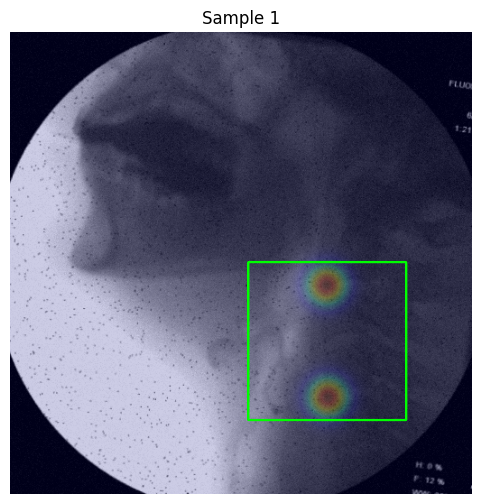

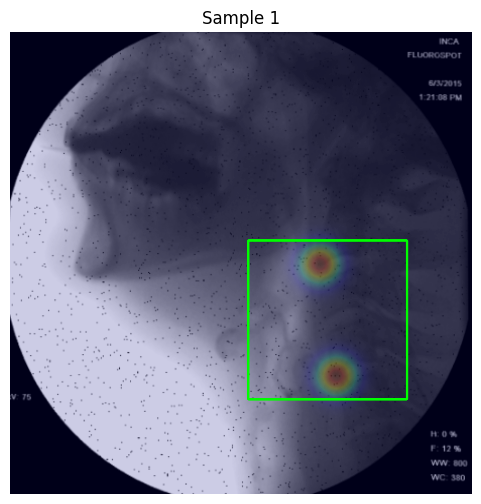

In [3]:
# VFSSImageDataset sem offline augmentation
transform = A.Compose([
    A.Resize(512, 512),

    A.PixelDropout(dropout_prob = 0.01, p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
    A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
    A.CropAndPad(px=(-30, 30), p=0.5),
    A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
    
    A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano

    ToTensorV2()
],
keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
)

data = VFSSImageDataset(video_frame_df = video_frame_df,
                 output_dim=(512,512),
                 transform = transform,
                 offline_augmentation = False,
                 sigma = 15)

data.plot_sample(1, False, True, True)
data.plot_sample(1, False, True, True)

In [ ]:
# Criando df com augmentation (salvando as imagens)

transform_offline = A.Compose([
    A.Resize(512, 512),

    A.PixelDropout(dropout_prob = 0.01, p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
    A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
    A.CropAndPad(px=(-30, 30), p=0.5),
    A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
    
    A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano

],
keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
)

new_rows_df = generate_offline_dataset(video_frame_df,
                                       transform_offline,
                                       save_dir="data/frames_augmentation",
                                       n_aug=2)

Processando frames:   0%|          | 0/941 [00:00<?, ?it/s]

v100_f10_aug6.png


Processando frames:   0%|          | 2/941 [00:00<01:16, 12.31it/s]

v100_f12_aug6.png


v100_f13_aug6.png


...

v12_f33_aug6.png


Processando frames:  15%|█▌        | 144/941 [00:10<00:56, 14.19it/s]

v12_f71_aug6.png


Processando frames:  15%|█▌        | 145/941 [00:11<01:00, 13.10it/s]


KeyboardInterrupt: 

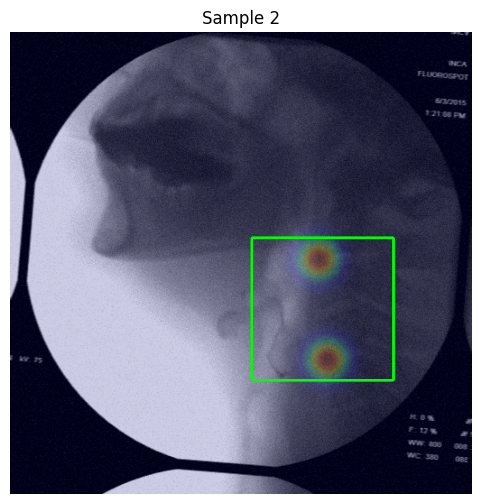

In [5]:
# VFSSImageDataset com offline augmentation
transform = A.Compose([A.Resize(512, 512)],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

data = VFSSImageDataset(video_frame_df = new_rows_df,
                 output_dim=(512,512),
                 transform = transform,
                 offline_augmentation = True,
                 sigma = 15)

data.plot_sample(2, False, True, True)

In [6]:
transform = A.Compose([
    A.Resize(512, 512),

    A.PixelDropout(dropout_prob = 0.01, p = 0.5),
    A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
    A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
    A.CropAndPad(px=(-30, 30), p=0.5),
    A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
    
    A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
    A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano

    ToTensorV2()
],
keypoint_params=A.KeypointParams(format='xy', label_fields=['keypoint_labels']),
)

# Read an image with OpenCV and convert it to the RGB colorspace
image = cv2.imread(r"C:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\data\frames\v33_f24.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

keypoints = load_points(r"C:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\data\rotulos\anotacoes-tecgraf\batch-1\AM\v33_f24\Results.csv")
keypoint_labels = [0, 1]
print(keypoints)

mask = np.array(generate_roi_from_points(keypoints, image.shape[0], image.shape[1]))
mask_labels = [0]

# Augment an image
transformed = transform(image=image,
                        mask=mask,
                        mask_labels=mask_labels,
                        keypoints=keypoints,
                        keypoint_labels=keypoint_labels)

transformed_image = transformed["image"]
transformed_image = transformed_image.permute(1,2,0)

transformed_keypoint = np.array(transformed["keypoints"])
transformed_keypoint_labels = transformed["keypoint_labels"]

transformed_mask = transformed['mask']
transformed_mask_labels = transformed['mask_labels']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))

ax[0].imshow(image)
ax[0].imshow(mask, cmap="jet", alpha=0.4)   # máscara
ax[0].scatter(keypoints[:,0], keypoints[:,1], c="r", s=5)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(transformed_image)
ax[1].imshow(transformed_mask, cmap="jet", alpha=0.4)   # máscara
ax[1].scatter(transformed_keypoint[:,0], transformed_keypoint[:,1], c="r", s=5)
ax[1].set_title("Transformada")
ax[1].axis("off")

plt.tight_layout()
plt.show()

FileNotFoundError: Arquivo de pontos não encontrado: C:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\data\rotulos\anotacoes-tecgraf\batch-1\AM\v33_f24\Results.csv\Results.csv